In [62]:
from matplotlib import pyplot as plt
import numpy as np
np.random.seed(12345)

Here is the link to my source code (source.py): https://github.com/cjy-2001/cjy-2001.github.io/blob/main/posts/unsupervised-post/unsupervised.py

## Summary

In this blog post, I will access my favorite RGB image from the internet by its URL, download it, and convert it to greyscale. Then I will write a function called svd_reconstruct that reconstructs an image from its singular value decomposition. The function has two arguments: the image to reconstruct, and the number k of singular values to use.

Then I will perform an experiment in which I reconstruct image with several different values of k. My choice of k will go up at least until I can’t distinguish the reconstructed image from the original by eye. As part of my experiment, I will also determine the amount of storage needed for my reconstruction as a fraction of the amount of storage needed for the original image.

### Implementation

I have defined a "SVD" class of methods that I'm going to use in my source file.

In [63]:
import unsupervised
import importlib
importlib.reload(unsupervised)
from unsupervised import SVD

svd = SVD()

### Image Selection

I use the following function to read an image from a URL and save it as a numpy array.

In [64]:
from PIL import Image
import urllib

def read_image(url):
    return np.array(Image.open((urllib.request.urlopen(url))))

url = "https://assets-global.website-files.com/621d30e84caf0be3291dbf1c/621fd069a48bdc8372addc60_alphago_02.jpg"

img = read_image(url)

I really enjoy playing the ancient Chinese board game, Go. I've chosen an image that shows this well. It's an RGB color image of two kids playing a game of Go.

 In the code below, I’ll convert it to greyscale.

(1149, 2048)

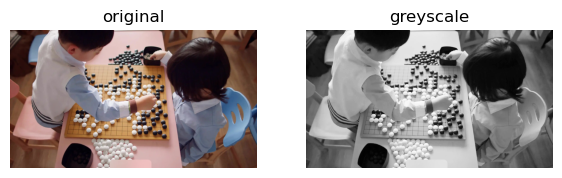

In [65]:
fig, axarr = plt.subplots(1, 2, figsize = (7, 3))

grey_img = svd.to_greyscale(img)

axarr[0].imshow(img)
axarr[0].axis("off")
axarr[0].set(title = "original")

axarr[1].imshow(grey_img, cmap = "Greys")
axarr[1].axis("off")
axarr[1].set(title = "greyscale")

grey_img.shape

### SVD_Reconstruct

I have also written a function named `svd_reconstruct` in my source file. It can reconstruct an image from its singular value decomposition based on the value k, which is the singular value.

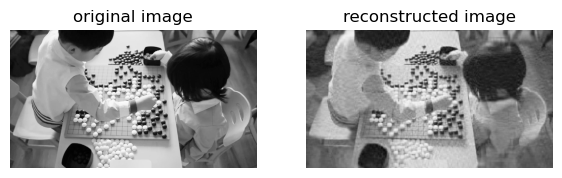

In [66]:
grey_img_ = svd.svd_reconstruct(img, 40)

svd.compare_images(grey_img, grey_img_)

As we can observe, with k set to 40, the reconstructed image appears somewhat blurry, but it's still recognizable. To better understand the impact of the singular value, k, let's conduct an experiment as follows.

### Experiment

I will perform an experiment in which I reconstruct image with several different values of k. 

- The experiment continued until I reached a point where I could no longer distinguish the reconstructed image from the original just by looking at it.
- As part of my experiment, I will also calculate the storage space required for the reconstructed image, expressing it as a fraction of the storage needed for the original image.

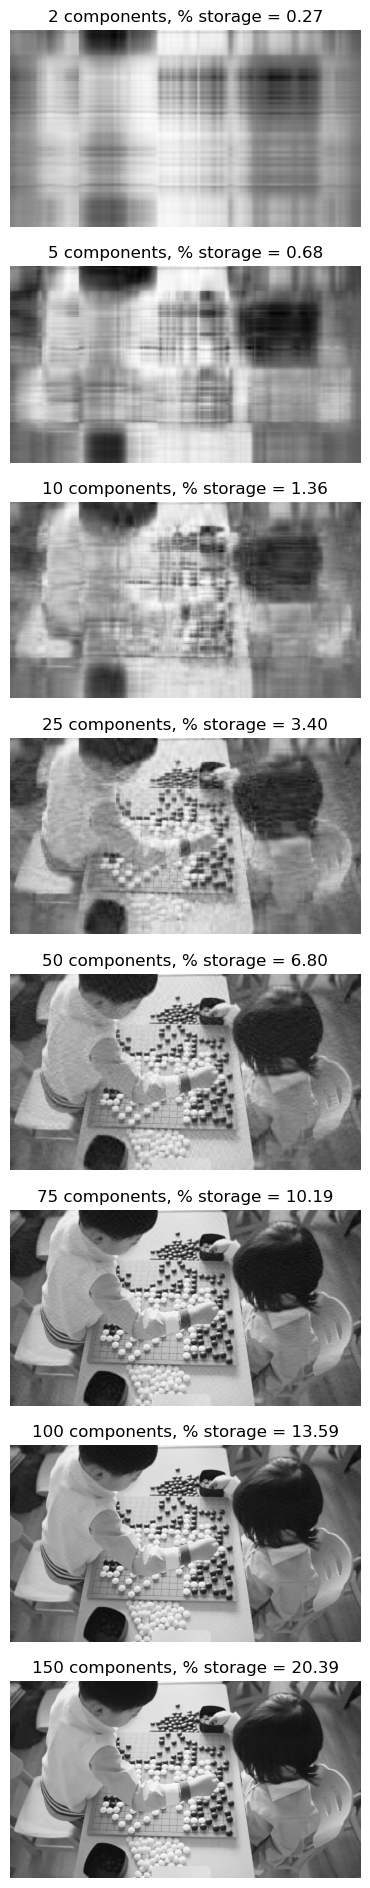

In [67]:
svd.svd_experiment(img)

I think when k was increased to about 150, the reconstructed image became almost indistinguishable from the original to the eye.

In this experiment, I computed the storage space required for the reconstructed image using Singular Value Decomposition (SVD). The SVD of a matrix produces three separate matrices: U, Σ, and V.

The U matrix has dimensions of m x k, Σ is a k x k diagonal matrix, and V is a k x n matrix. Then to calculate the total storage requirement for these three matrices, we add up the number of elements in each:

- The U matrix has m*k elements.
- Since the Σ matrix is transformed to the D matrix, it has k elements.
- The V matrix has n*k elements.

Therefore, the total storage needed is k * (m + n + 1). Then I just divide it by m x n.